**FOOD RECOGNITION AND CALORIE ESTIMATION-MULTITASK CNN MODEL**

---



The increasing prevalence of lifestyle‑related diseases such as obesity, diabetes, and cardiovascular disorders has created a growing need for accurate and convenient dietary monitoring tools. Traditional calorie‑tracking methods rely heavily on manual input, which is time‑consuming, error‑prone, and often discourages long‑term user engagement. With the widespread availability of smartphones and advancements in computer vision, there is a strong opportunity to automate food analysis using deep learning.

This project builds an intelligent system that can identify food items from images and estimate their calorie content using deep learning.
It combines image classification and regression into a single multi‑task model, making it both efficient and practical for real‑world use cases such as:

Diet tracking

Fitness apps

Restaurant menu analysis

Health monitoring


**PROBLEM STATEMENT**

---



The main objective of this project is to develop a deep learning-based food recognition and calorie estimation system using Convolutional Neural Networks (CNNs). The system uses the Food-11 image dataset to classify different categories of food items and estimate their nutritional information such as calories, carbohydrates, proteins, fats, fiber, sugar, and sodium.

The proposed model utilizes transfer learning with EfficientNetB0 to improve classification accuracy and reduce training time. The system preprocesses food images, performs image classification, and retrieves nutritional details from a nutrition dataset. A Streamlit-based frontend application is also developed to allow users to upload food images and receive instant predictions and calorie estimations.

**DATASETS**

---



*1.Food-11 Image Dataset*

The Food-11 dataset is a publicly available food image classification dataset used for deep learning and computer vision tasks. It contains approximately 16,000 food images categorized into 11 different food classes. The dataset is widely used for food recognition applications and CNN-based image classification projects.

*DATASET SOURCE* :

Kaggle Dataset

*Dataset Size:*

Total Images	~16,000

Number of Classes	- 11

Image Type	- JPG Images

Dataset Type - 	Image Classification

Dataset Format	- based

*2.NUTRITION CSV FILE*

A custom nutrition CSV file was created to store:

-Calories

-Carbohydrates

-Protein

-Fat

-Fiber

-Sugar

-Sodium

This CSV dataset is linked with the CNN prediction system to estimate nutritional information after food classification.

**IMPORTS**

---



In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import os
from tensorflow.keras.applications.efficientnet import preprocess_input

**LOAD DATASET**

---



In [6]:
import json

kaggle_config = {
    "username":"rinsanapk",
    "key" : "KGAT_f165cb96a40909d0b003d0ded202e5f4"
}

with open("kaggle.json","w") as f:
  json.dump(kaggle_config,f)

print("kaggle.json file created")

kaggle.json file created


In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.08G/1.08G [00:14<00:00, 79.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/trolukovich/food11-image-dataset/versions/1


In [9]:
!kaggle datasets download -d trolukovich/food11-image-dataset

Dataset URL: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset
License(s): CC0-1.0
100% 1.08G/1.08G [00:13<00:00, 83.3MB/s]



In [10]:
import zipfile     #unzip dataset

zip_path = '/content/food11-image-dataset.zip'
extract_path = '/content/food11'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [11]:
os.listdir('/content/food11')

['evaluation', 'training', 'validation']

In [12]:
train_dir = '/content/food11/training'
val_dir = '/content/food11/validation'
test_dir = '/content/food11/evaluation'

**LOAD NUTRITION CSV**

---



In [13]:
csv_path = '/content/food11_calories_full.csv'
nutrition_df = pd.read_csv(csv_path)

nutrition_df.head()

,class_name,calories,calorper_ies_100g,portion_size_g,carbs_g,protein_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg
0,Bread,265,265,100,49.0,9.0,3.2,2.7,5.0,491,0
1,Dairy product,150,150,100,12.0,8.0,8.0,0.0,11.0,105,30
2,Dessert,350,350,100,50.0,5.0,15.0,1.5,35.0,250,45
3,Egg,155,155,100,1.1,13.0,11.0,0.0,1.1,124,373
4,Fried food,320,320,100,28.0,7.0,20.0,2.0,1.5,450,40


CHECK DATASET SHAPE:

In [14]:
print("Dataset Shape:")
print(nutrition_df.shape)

Dataset Shape:
(11, 11)


DISPLAY COLOUMNS:

In [15]:
print("Dataset Columns:")
print(nutrition_df.columns)

Dataset Columns:
Index(['class_name', 'calories', 'calorper_ies_100g', 'portion_size_g',
       'carbs_g', 'protein_g', 'fat_g', 'fiber_g', 'sugar_g', 'sodium_mg',
       'cholesterol_mg'],
      dtype='object')


CHECKING DATATYPES,MISSING VALUES & DUPLICATE VALUES:

In [16]:
print(nutrition_df.dtypes)

class_name            object
calories               int64
calorper_ies_100g      int64
portion_size_g         int64
carbs_g              float64
protein_g            float64
fat_g                float64
fiber_g              float64
sugar_g              float64
sodium_mg              int64
cholesterol_mg         int64
dtype: object


In [17]:
print("Missing Values:")
print(nutrition_df.isnull().sum())

Missing Values:
class_name           0
calories             0
calorper_ies_100g    0
portion_size_g       0
carbs_g              0
protein_g            0
fat_g                0
fiber_g              0
sugar_g              0
sodium_mg            0
cholesterol_mg       0
dtype: int64


Insight

This checks whether any feature contains null or missing values.

Why important: Missing values can affect calorie estimation and cause preprocessing issues.

Expected output: All columns should ideally show 0 missing values.

Deep Learning Insight: Data cleaning is an important preprocessing step before model training.

In [18]:
print("Duplicate Rows:", nutrition_df.duplicated().sum())

Duplicate Rows: 0


**VISUALIZE CALORIES DISTRIBUTION**

---



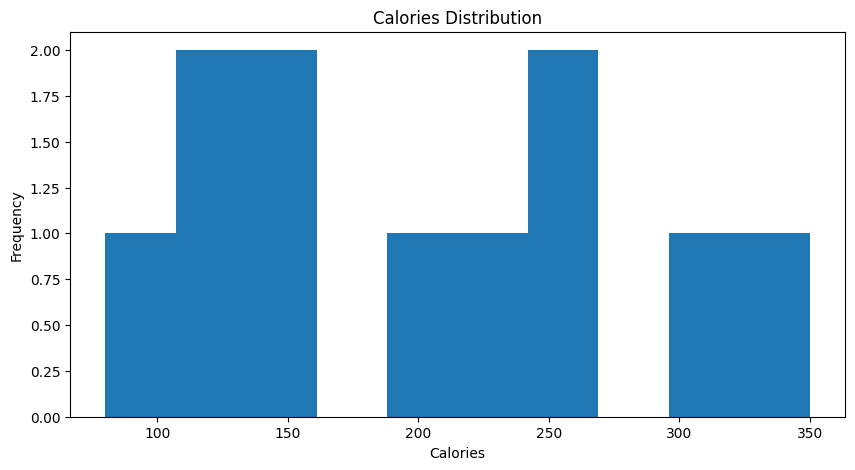

In [19]:
plt.figure(figsize=(10,5))

plt.hist(nutrition_df['calories'], bins=10)

plt.title('Calories Distribution')
plt.xlabel('Calories')
plt.ylabel('Frequency')

plt.show()

-Most food items fall within the medium calorie range.

-Some food classes such as fried foods and desserts contain higher calorie values.

-Low-calorie foods like vegetables and soups appear less calorie-dense.

The CNN model classifies food images, while the calorie distribution helps analyze nutritional trends across predicted classes

**VISUALIZE PROTEIN DISTRIBUTION**

---



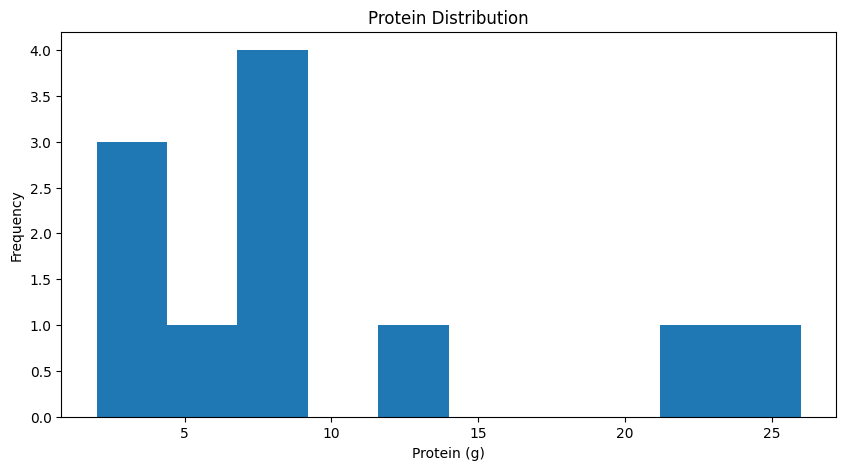

In [20]:
plt.figure(figsize=(10,5))

plt.hist(nutrition_df['protein_g'], bins=10)

plt.title('Protein Distribution')
plt.xlabel('Protein (g)')
plt.ylabel('Frequency')

plt.show()

-Protein values are higher in meat, seafood, egg, and dairy products.

-Vegetables, fruits, soups, and desserts generally contain lower protein levels.

-The dataset contains both low-protein and high-protein food categories.

After food classification, protein estimation helps users understand the nutritional quality of predicted foods.

**CORRELATION HEATMAP**

---



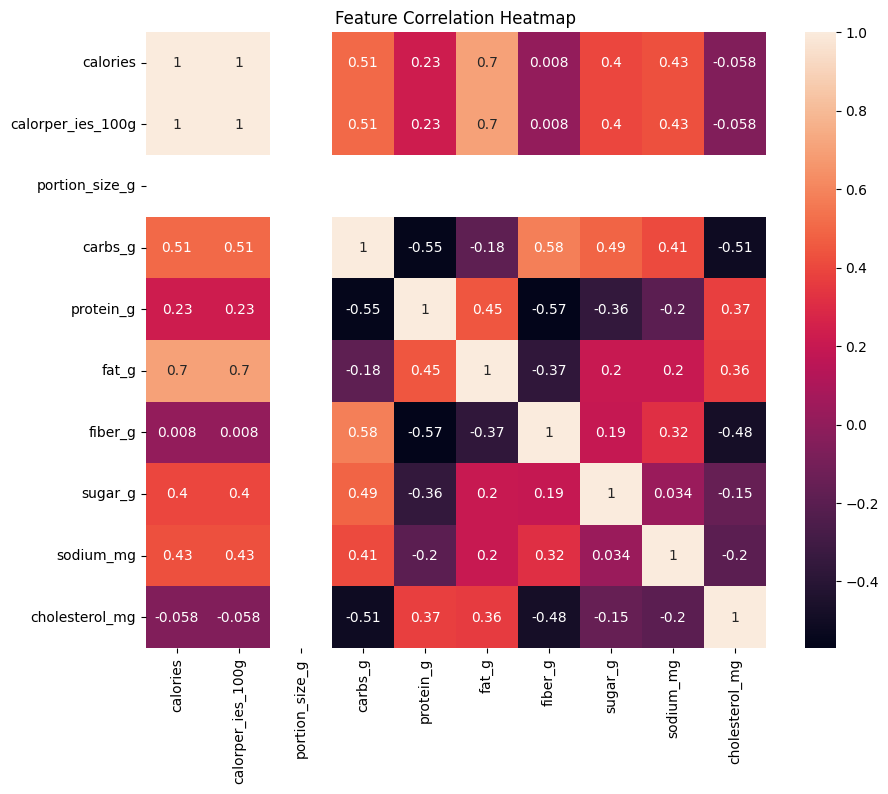

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(nutrition_df.corr(numeric_only=True), annot=True)

plt.title('Feature Correlation Heatmap')

plt.show()

The correlation heatmap visualizes the relationship between nutritional features such as calories, carbohydrates, protein, fat, fiber, sugar, and sodium.

Observation:

-Calories show a strong positive correlation with fat and carbohydrates.

-Protein is positively correlated with meat, seafood, and dairy-related nutritional values.

-Sugar has moderate correlation with calories, especially in desserts.

-Fiber generally has lower correlation with fat and calories.

-Sodium shows variation across processed and fried foods.

**IMAGE PREPROCESSING**

---



In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32

**DATA AUGMENTATION**

---



In [23]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

INSIGHT:

This cell performs image preprocessing and augmentation.

Why Important
Increases dataset diversity
Reduces overfitting
Improves model generalization

In [24]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.


Loads images from dataset folders and automatically assigns labels.

-Creates batches

-Feeds images into CNN

-Converts folder names into class labels

Deep Learning Insight:

CNN models perform better when exposed to varied image orientations and transformations.

**LOAD DATASET**

---



In [25]:
from tensorflow.keras.applications.efficientnet import preprocess_input

**DISPLAY SAMPLE IMAGES FROM DATASET**

---



In [26]:
import random
from tensorflow.keras.preprocessing import image

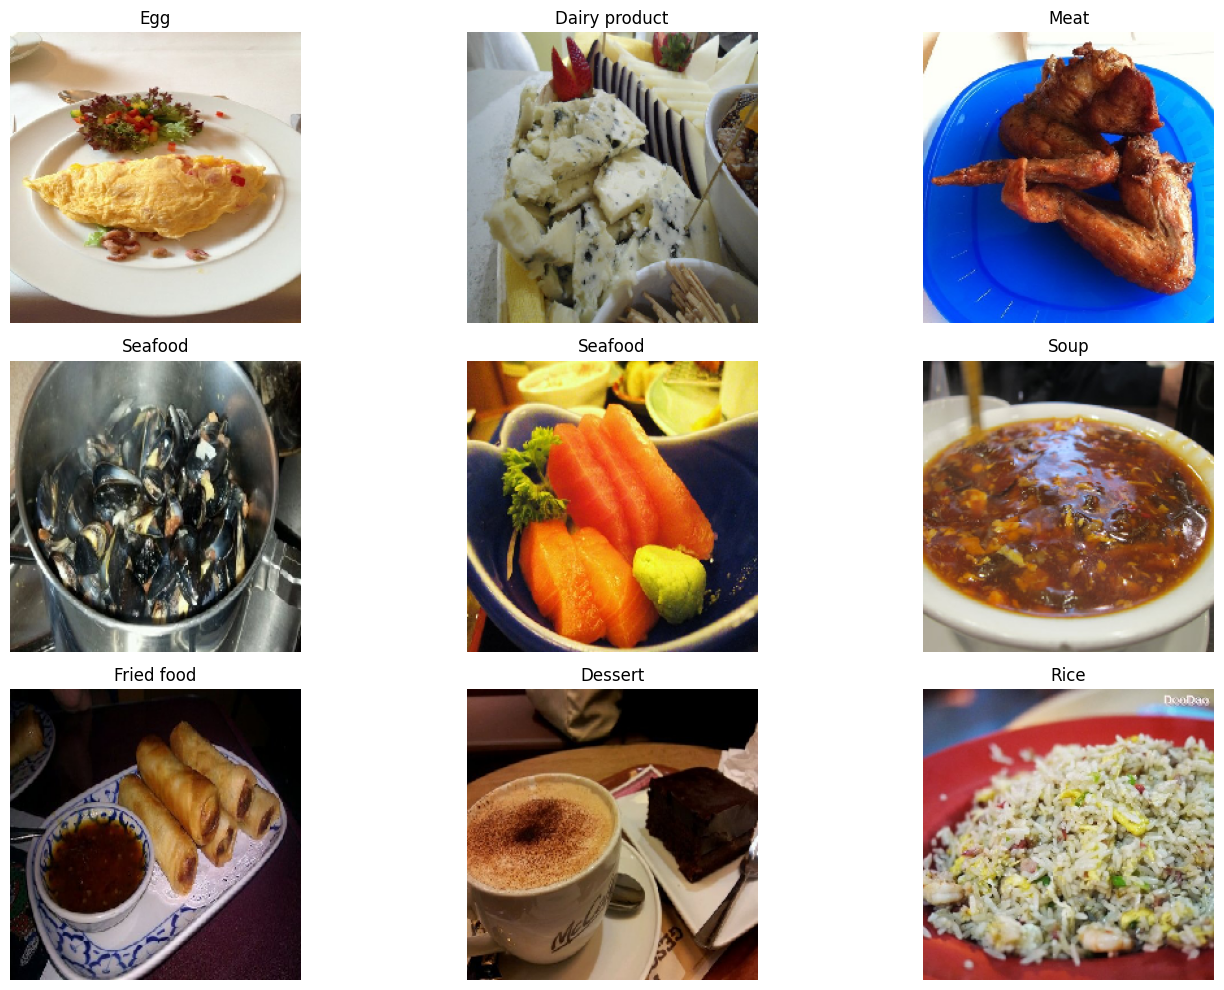

In [27]:
sample_classes = os.listdir(train_dir)

plt.figure(figsize=(15,10))

for i in range(9):

    class_name = random.choice(sample_classes)

    class_path = os.path.join(train_dir, class_name)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = image.load_img(img_path, target_size=(224,224))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

INSIGHT:

This section visualizes random food images from the dataset.

Why important:

Verifies dataset loading
Confirms image quality
Helps understand class diversity

Deep Learning Insight: CNN models learn spatial image features such as edges, textures, and shapes.

DISPLAY CLASS LABELS:

In [28]:
print(train_generator.class_indices)

{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


**BUILD CNN MODEL**

---



INSIGHT:

This section loads the pretrained EfficientNetB0 model.

Why important:

Uses transfer learning
Improves accuracy
Reduces training time

Expected output: EfficientNetB0 loads pretrained ImageNet weights.

Deep Learning Insight: Transfer learning allows CNNs to reuse previously learned image features.

In [29]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True     #FINETUNING

for layer in base_model.layers[:-20]:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


INSIGHT:

This section loads the pretrained EfficientNetB0 model.

Why important:

Uses transfer learning
Improves accuracy
Reduces training time

Deep Learning Insight: Transfer learning allows CNNs to reuse previously learned image features

FINETUNING INSIGHT:

Enables fine-tuning for the final layers of EfficientNetB0.

-Learns Food-11 specific features
-Improves classification accuracy

Deep Learning Insight:

Fine-tuning adapts pretrained CNN features to domain-specific datasets.

CREATE FINAL MODEL:(BATCH NORMALIZATION)

In [30]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.3),

    Dense(256, activation='relu'),

    BatchNormalization(),

    Dropout(0.3),

    Dense(11, activation='softmax')

])

INSIGHT:

Normalizes activations during training.

-Stabilizes learning
-Speeds up convergence
-Improves validation accuracy

Deep Learning Insight:

Batch normalization reduces internal covariate shift in deep neural networks.

-Dropout improves model generalization by reducing dependency on specific neurons.

**COMPILE MODEL**

---



In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

INSIGHT:

Configures the CNN training process.

-Adam optimizer updates weights efficiently
-Crossentropy measures classification error
-Accuracy evaluates prediction performance
Deep Learning Insight:

Loss minimization helps CNN models learn meaningful image representations.

**MODEL SUMMARY**

---



In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,478 (16.73 MB)

 Trainable params: 1,684,795 (6.43 MB)

 Non-trainable params: 2,701,683 (10.31 MB)

**EARLY STOPPING**

---



In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.000001
)

**TRAIN MODEL**

---



In [35]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1259s 4s/step - accuracy: 0.5693 - loss: 1.4084 - val_accuracy: 0.8254 - val_loss: 0.5737 - learning_rate: 1.0000e-04
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1246s 4s/step - accuracy: 0.7833 - loss: 0.6924 - val_accuracy: 0.8630 - val_loss: 0.4506 - learning_rate: 1.0000e-04
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1243s 4s/step - accuracy: 0.8342 - loss: 0.5417 - val_accuracy: 0.8770 - val_loss: 0.4018 - learning_rate: 1.0000e-04
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1231s 4s/step - accuracy: 0.8537 - loss: 0.4542 - val_accuracy: 0.8860 - val_loss: 0.3671 - learning_rate: 1.0000e-04
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1288s 4s/step - accuracy: 0.8711 - loss: 0.3968 - val_accuracy: 0.8915 - val_loss: 0.3557 - learning_rate: 1.0000e-04
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1221s 4s/step - accuracy: 0.8833 - loss: 0.3509 - val_accuracy: 0.8959 - val_loss: 0.3395 - learning_rate: 1.0000e-04
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 1208s 4s/ste

In [36]:
print(train_generator.class_indices)

{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


INSIGHT:

Trains the CNN model using Food-11 images.

-Learns food image patterns

-Updates neural network weights

-Evaluates validation performance

Validation accuracy helps monitor generalization and detect overfitting.

**SAVE THE MODEL**

---



In [37]:
model.save('food11_model.keras')

**DOWNLOAD**

---



In [38]:
from google.colab import files
files.download("food11_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**PLOT ACCURACY GRAPH**

---



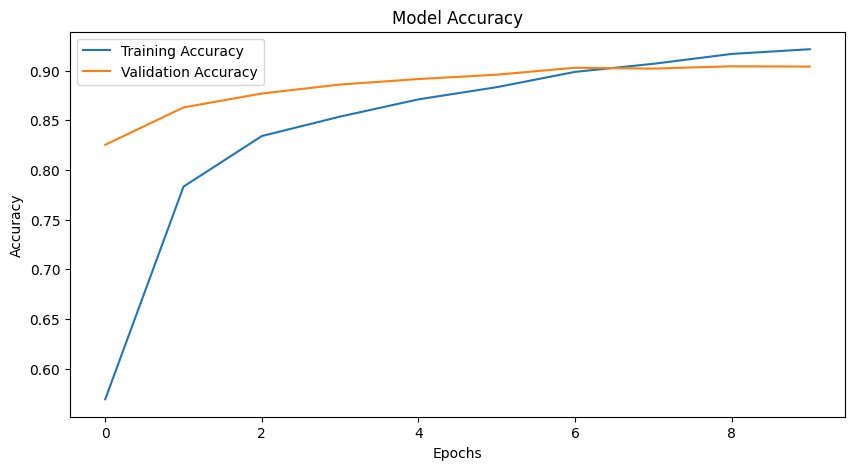

In [39]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

INSIGHT:

Visualizes training and validation accuracy.

-Shows how well the model is learning.

Deep Learning Insight: If training accuracy is very high but validation accuracy is low, overfitting may occur.

**PLOT LOSS GRAPH**

---



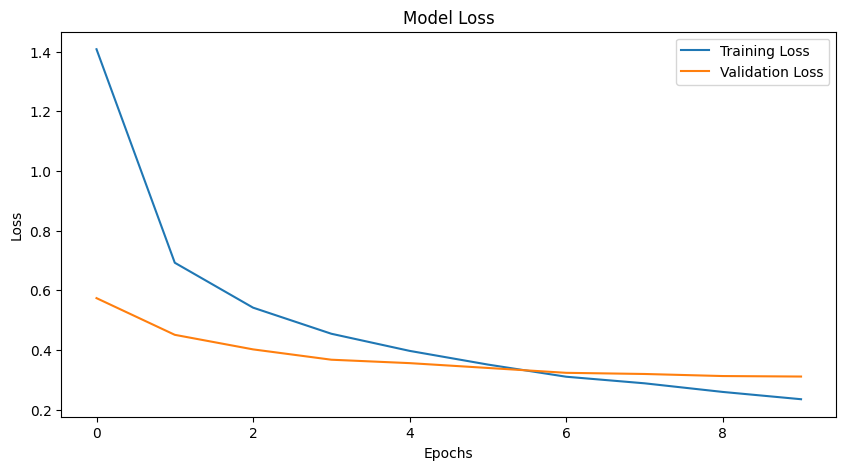

In [40]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

INSIGHT:

Visualizes prediction error during training.

Lower loss indicates improved model learning.

Deep Learning Insight

Validation loss is a strong indicator of model generalization quality.

**CONFUSION MATRIX**

---



105/105 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step


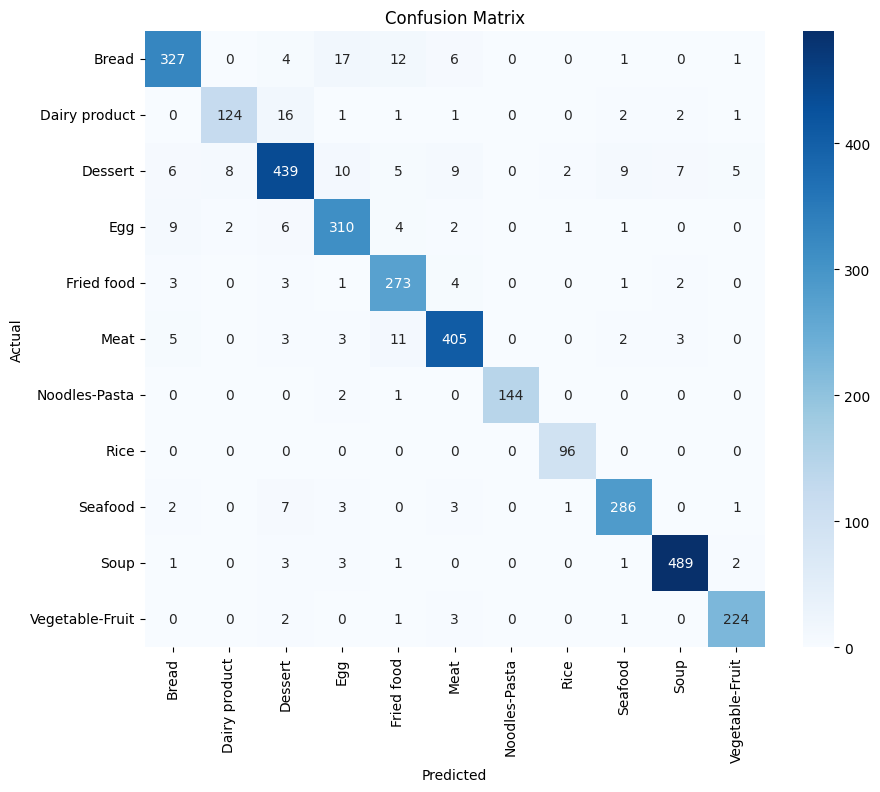

In [41]:
test_labels = test_generator.classes
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get class labels in the order of the generator
class_labels = list(train_generator.class_indices.keys())

cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

INSIGHT:

Displays correct and incorrect predictions for each food category.


-Helps identify difficult food classes.

Deep Learning Insight:

Confusion matrices provide class-wise CNN performance evaluation.



## EVALUATION

---


### 1. Test Accuracy & Loss

In [42]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy*100:.2f}%')

105/105 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.9313 - loss: 0.2429

Test Loss     : 0.2429
Test Accuracy : 93.13%


**Insight:**

- `test_loss` measures how far the model's predictions are from the true labels on unseen data.
- `test_accuracy` is the primary metric — percentage of images correctly classified.
- A high test accuracy (>80%) with low loss confirms the model generalises well.

### 2. Classification Report (Precision, Recall, F1-Score)

In [44]:
from sklearn.metrics import classification_report

# Re-predict on test set (in case model was reloaded)
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(train_generator.class_indices.keys())

report = classification_report(true_classes, predicted_classes,
                               target_names=class_labels, digits=4)
print(report)

105/105 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step
                 precision    recall  f1-score   support

          Bread     0.9263    0.8886    0.9071       368
  Dairy product     0.9254    0.8378    0.8794       148
        Dessert     0.9089    0.8780    0.8932       500
            Egg     0.8857    0.9254    0.9051       335
     Fried food     0.8835    0.9512    0.9161       287
           Meat     0.9353    0.9375    0.9364       432
  Noodles-Pasta     1.0000    0.9796    0.9897       147
           Rice     0.9600    1.0000    0.9796        96
        Seafood     0.9408    0.9439    0.9423       303
           Soup     0.9722    0.9780    0.9751       500
Vegetable-Fruit     0.9573    0.9697    0.9634       231

       accuracy                         0.9313      3347
      macro avg     0.9359    0.9354    0.9352      3347
   weighted avg     0.9316    0.9313    0.9311      3347



**Insight:**

- **Precision** — of all images predicted as class X, how many were actually X.
- **Recall** — of all actual class X images, how many were correctly predicted.
- **F1-Score** — harmonic mean of precision and recall; useful when classes are imbalanced.
- **Support** — number of true instances per class in the test set.
- Low recall for a class (e.g. Soup, Noodles) indicates visual ambiguity that the CNN struggles with.

### 3. Per-Class Accuracy Bar Chart

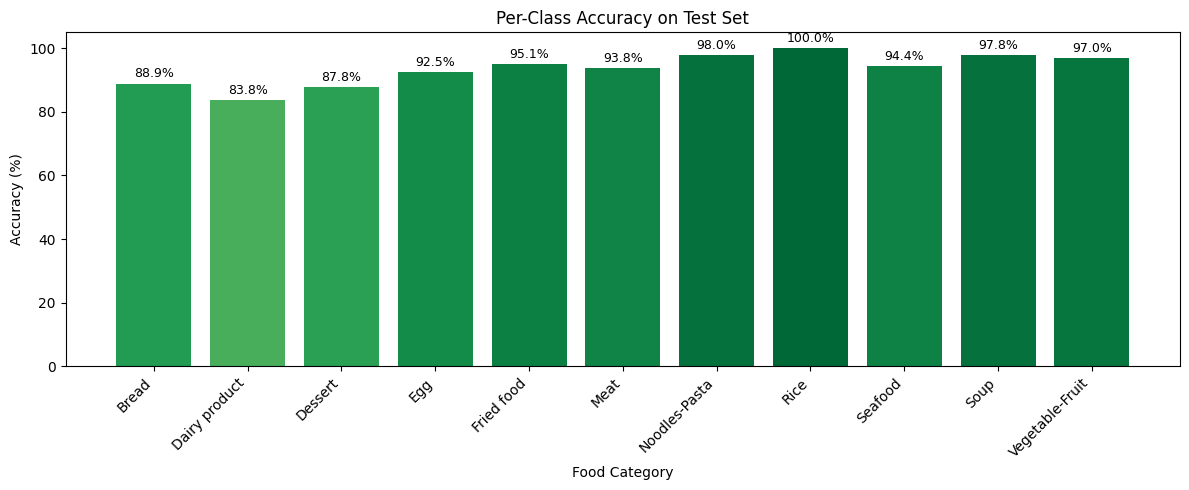

In [45]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

# Per-class accuracy = diagonal / row sum
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_labels, per_class_acc * 100,
               color=plt.cm.RdYlGn(per_class_acc))
plt.xlabel('Food Category')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy on Test Set')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**

- Green bars indicate high accuracy classes; red bars highlight weaker classes.
- Classes with lower accuracy may share visual features with other categories (e.g. Fried Food vs Meat).
- This guides targeted data augmentation or class-specific fine-tuning.

### 4. Top-3 Accuracy

In [46]:
# Top-K accuracy: correct if true label is in top-K predictions
K = 3

top_k_correct = 0
for i, true_label in enumerate(true_classes):
    top_k_preds = np.argsort(predictions[i])[::-1][:K]
    if true_label in top_k_preds:
        top_k_correct += 1

top_k_accuracy = top_k_correct / len(true_classes)
print(f'Top-{K} Accuracy on Test Set: {top_k_accuracy*100:.2f}%')

Top-3 Accuracy on Test Set: 98.69%


**Insight:**

- Top-3 accuracy checks if the correct label appears within the 3 highest-confidence predictions.
- Useful for real-world apps where the model can suggest multiple options to the user.
- A high Top-3 but moderate Top-1 accuracy indicates the model is on the right track but needs refinement.

### 5. Confidence Distribution

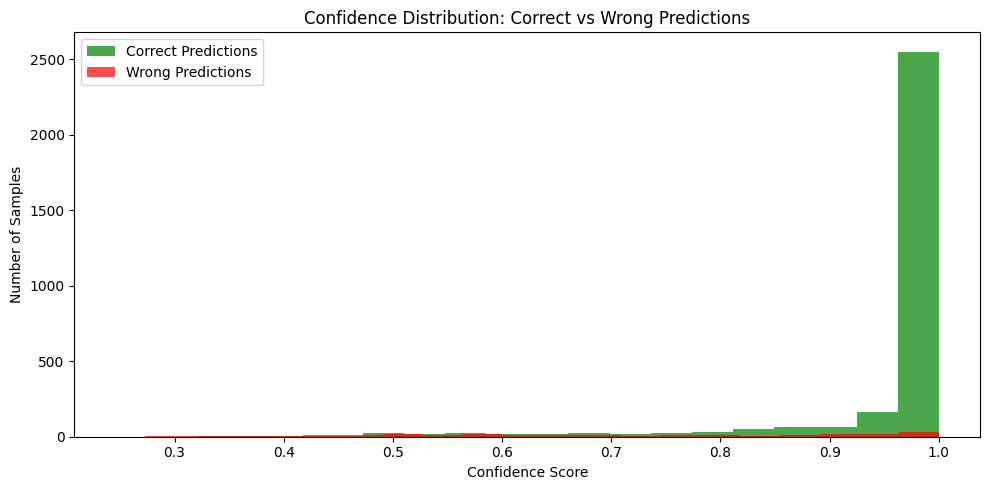

Average confidence (correct)  : 96.06%
Average confidence (incorrect): 70.61%


In [47]:
max_confidences = np.max(predictions, axis=1)
correct_mask = (predicted_classes == true_classes)

plt.figure(figsize=(10, 5))
plt.hist(max_confidences[correct_mask], bins=20, alpha=0.7,
         color='green', label='Correct Predictions')
plt.hist(max_confidences[~correct_mask], bins=20, alpha=0.7,
         color='red', label='Wrong Predictions')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Samples')
plt.title('Confidence Distribution: Correct vs Wrong Predictions')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average confidence (correct)  : {max_confidences[correct_mask].mean()*100:.2f}%')
print(f'Average confidence (incorrect): {max_confidences[~correct_mask].mean()*100:.2f}%')

**Insight:**

- Ideally, correct predictions cluster at high confidence (>0.8) and wrong predictions at low confidence.
- If wrong predictions also have high confidence, the model is overconfident — a sign of overfitting.
- This analysis is critical for setting a confidence threshold in the Streamlit deployment.

### 6. Evaluation Summary

In [48]:
print('=' * 45)
print('       MODEL EVALUATION SUMMARY')
print('=' * 45)
print(f'  Test Loss           : {test_loss:.4f}')
print(f'  Test Accuracy       : {test_accuracy*100:.2f}%')
print(f'  Top-3 Accuracy      : {top_k_accuracy*100:.2f}%')
best_class = class_labels[np.argmax(per_class_acc)]
worst_class = class_labels[np.argmin(per_class_acc)]
print(f'  Best Class          : {best_class} ({per_class_acc.max()*100:.1f}%)')
print(f'  Weakest Class       : {worst_class} ({per_class_acc.min()*100:.1f}%)')
print(f'  Avg Conf (correct)  : {max_confidences[correct_mask].mean()*100:.2f}%')
print(f'  Avg Conf (wrong)    : {max_confidences[~correct_mask].mean()*100:.2f}%')
print('=' * 45)

       MODEL EVALUATION SUMMARY
  Test Loss           : 0.2429
  Test Accuracy       : 93.13%
  Top-3 Accuracy      : 98.69%
  Best Class          : Rice (100.0%)
  Weakest Class       : Dairy product (83.8%)
  Avg Conf (correct)  : 96.06%
  Avg Conf (wrong)    : 70.61%


**FOOD PREDICTION & CALORIE ESTIMATION**

---



In [50]:
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load trained model
model = load_model("food11_model.keras")

# Load nutrition dataset
nutrition_df = pd.read_csv("food11_calories_full.csv")

# Class names (must match training order)
class_names = [
    "Bread",
    "Dairy Product",
    "Dessert",
    "Egg",
    "Fried Food",
    "Meat",
    "Noodles/Pasta",
    "Rice",
    "Seafood",
    "Soup",
    "Vegetable/Fruit"
]

# Load image
image_path = "SAMPLE1.jpg"

img = Image.open(image_path).convert("RGB")
img = img.resize((224,224))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)

# EfficientNet preprocessing
img_array = preprocess_input(img_array)

# Prediction
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction)

food_name = class_names[predicted_index]

print("Predicted Food:", food_name)
print("Confidence:", round(confidence*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Food: Rice
Confidence: 65.65 %


CALORIE ESTIMATION CODE:

In [52]:
# Nutrition Lookup

nutrition = nutrition_df[
    nutrition_df["class_name"] == food_name
]

if len(nutrition) > 0:

    row = nutrition.iloc[0]

    print("\nNutrition Information")

    print("Calories:", row["calories"], "kcal")
    print("Protein:", row["protein_g"], "g")
    print("Carbohydrates:", row["carbs_g"], "g")
    print("Fat:", row["fat_g"], "g")
    print("Fiber:", row["fiber_g"], "g")
    print("Sugar:", row["sugar_g"], "g")
    print("Sodium:", row["sodium_mg"], "mg")


Nutrition Information
Calories: 130 kcal
Protein: 2.7 g
Carbohydrates: 28.0 g
Fat: 0.3 g
Fiber: 0.4 g
Sugar: 0.1 g
Sodium: 1 mg


LOAD IMAGE FUNCTION:

INSIGHT:

This section predicts food class from an uploaded image and retrieves nutrition details.

- Combines CNN classification with calorie estimation.

Deep Learning Insight:
This creates a real-world AI nutrition analysis application.

**TEST PREDICTION**

---



In [53]:
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Define the predict_food function by encapsulating the prediction and nutrition lookup logic.
# This definition is placed here to resolve the NameError when predict_food is called in this cell.
# This assumes 'model', 'nutrition_df', and 'class_names' are globally available from previously executed cells.
def predict_food(image_path):
    # Load image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224,224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # EfficientNet preprocessing
    img_array = preprocess_input(img_array)

    # Prediction
    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)

    food_name = class_names[predicted_index]

    print("Predicted Food:", food_name)
    print("Confidence:", round(confidence*100,2), "%")

    # Nutrition Lookup
    nutrition = nutrition_df[
        nutrition_df["class_name"] == food_name
    ]

    if len(nutrition) > 0:
        row = nutrition.iloc[0]
        print("\nNutrition Information")
        print("Calories:", row["calories"], "kcal")
        print("Protein:", row["protein_g"], "g")
        print("Carbohydrates:", row["carbs_g"], "g")
        print("Fat:", row["fat_g"], "g")
        print("Fiber:", row["fiber_g"], "g")
        print("Sugar:", row["sugar_g"], "g")
        print("Sodium:", row["sodium_mg"], "mg")
    else:
        print("\nNutrition information not found for:", food_name)

# Call the predict_food function
predict_food('/content/SAMPLE1.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Predicted Food: Rice
Confidence: 65.65 %

Nutrition Information
Calories: 130 kcal
Protein: 2.7 g
Carbohydrates: 28.0 g
Fat: 0.3 g
Fiber: 0.4 g
Sugar: 0.1 g
Sodium: 1 mg


DISPLAY IMAGE WHILE PREDICTING:

In [54]:
import matplotlib.pyplot as plt

def show_prediction(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    predict_food(img_path)

FINAL PREDICTION:

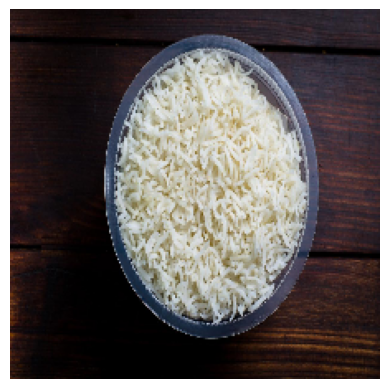

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted Food: Rice
Confidence: 65.65 %

Nutrition Information
Calories: 130 kcal
Protein: 2.7 g
Carbohydrates: 28.0 g
Fat: 0.3 g
Fiber: 0.4 g
Sugar: 0.1 g
Sodium: 1 mg


In [55]:
from tensorflow.keras.preprocessing import image
show_prediction('/content/SAMPLE1.jpg')

**INSTALL STREAMLIT**

---



In [56]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.2 MB/s eta 0:00:00


**RUN STREAMLIT APP**

---



In [57]:
!curl -4 icanhazip.com

34.26.71.79


In [59]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [60]:
!streamlit run app.py &>/content/streamlit.log &

In [61]:
import time
time.sleep(3)
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://common-parts-like.loca.lt
^C
